# Chapter 4: The Intelligent Adaptive Pipeline

## 4.1 Objective
Previous experiments demonstrated that static pipelines fail when subjected to highly variable underwater environments. This chapter introduces an **Adaptive Routing System**. 

By utilizing the multi-label dataset profile generated in Chapter 3, this system autonomously intercepts each raw image, reads its specific optical degradation tags, and executes a customized sequence of algorithms to correct those exact issues.

## 4.2 Algorithm Sequence & Empirical Calibration
During calibration, it was observed that severe degradation requires a cascaded hybrid approach to satisfy both UCIQE (colorfulness) and UIQM (structural sharpness):

1. **Spectral Correction (CIELAB Shift):** Executed first to restore physically absorbed red wavelengths in deep-sea datasets.
2. **Illumination & Backscatter Correction (Homomorphic + CLAHE):** Normalizes lighting and stretches global contrast. 
3. **Red-Overshoot Neutralization (Gray-World):** Contrast stretching in turbid images often artificially amplifies the red channel. An adaptive white-balance is applied here to neutralize unnatural color spikes.
4. **High-Frequency Detail Fusion:** Because Homomorphic filtering can soften structural edges, the corrected image is cascaded into a Multi-Scale Fusion block. This final step restores high-frequency Sobel edges, critically improving the UIQM score.

> **Calibration Note for Researchers:** The parameters within these algorithms (e.g., CLAHE `clipLimit`, CIELAB `shift_a`) can be calibrated. If the final output of a "Deep Sea" image appears too red, the `shift_a` parameter inside the router function must be reduced.

In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
from tqdm import tqdm

# Paths
RAW_PATH = "C:/Users/huiki/Desktop/FYP/data/raw/uieb/"
CSV_PROFILE = "C:/Users/huiki/Desktop/FYP/data/processed/uieb_dataset_profile.csv"
ADAPTIVE_OUT = "C:/Users/huiki/Desktop/FYP/data/processed/adaptive_pipeline/"
os.makedirs(ADAPTIVE_OUT, exist_ok=True)

# Load the dataset profile
df_profile = pd.read_csv(CSV_PROFILE)

# ==========================================
# ALGORITHM DEFINITIONS
# ==========================================

def apply_cielab_shift(img, shift_a=8, shift_b=15):
    """
    Shifts color channels in CIELAB space to restore absorbed red/yellow light.
    [CALIBRATION]: 
    - shift_a (Red/Green): If deep sea images look too aggressively pink/red, lower this to 4 or 5.
    - shift_b (Blue/Yellow): If the water looks too purple, lower this to 10.
    """
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    a = cv2.add(a, shift_a)
    b = cv2.add(b, shift_b)
    lab_shifted = cv2.merge((l, a, b))
    return cv2.cvtColor(lab_shifted, cv2.COLOR_LAB2BGR)

def compensate_green_water(img, green_suppression=0.85, red_boost=1.3, blue_boost=1.1):
    """
    Suppresses dominant green algae/phytoplankton and restores Red/Blue.
    [CALIBRATION]: 
    - green_suppression: Lower this (<0.8) if the image is still too overwhelmingly green.
    - red_boost: Decrease (<1.3) if the sand or rocks start looking artificially orange.
    """
    b, g, r = cv2.split(img.astype(np.float32))
    r = np.clip(r * red_boost, 0, 255)
    b = np.clip(b * blue_boost, 0, 255)
    g = np.clip(g * green_suppression, 0, 255)
    return cv2.merge((b, g, r)).astype(np.uint8)

def gray_world_white_balance(img):
    """
    Pre-conditions the image by balancing color channels. 
    This stops the "Red Explosion" from happening when CLAHE stretches the contrast.
    """
    result = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    avg_a = np.average(result[:, :, 1])
    avg_b = np.average(result[:, :, 2])
    result[:, :, 1] = result[:, :, 1] - ((avg_a - 128) * (result[:, :, 0] / 255.0) * 1.1)
    result[:, :, 2] = result[:, :, 2] - ((avg_b - 128) * (result[:, :, 0] / 255.0) * 1.1)
    return cv2.cvtColor(result, cv2.COLOR_LAB2BGR)

def hybrid_turbid_enhancement(img, clip_limit=1.8, saturation_scale=1.3, sharpen_weight=1.6):
    """
    Protects UIQM (Sharpness) while boosting visibility in dark/hazy images.
    [CALIBRATION]:
    - clip_limit: Lower to 1.5 if the image gets too bright or creates "halo" artifacts.
    - saturation_scale: Increase to 1.5 if the image looks washed out/gray.
    - sharpen_weight: Increase to 2.0 to force a higher UIQM edge score (but watch out for noise).
    """
    # 1. Contrast without breaking color (CLAHE on L channel)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=(8,8))
    cl = clahe.apply(l)
    contrast_img = cv2.cvtColor(cv2.merge((cl, a, b)), cv2.COLOR_LAB2BGR)
    
    # 2. Controlled Colorfulness (Boost S channel in HSV)
    hsv = cv2.cvtColor(contrast_img, cv2.COLOR_BGR2HSV).astype(np.float32)
    h, s, v = cv2.split(hsv)
    s = np.clip(s * saturation_scale, 0, 255) 
    color_img = cv2.cvtColor(cv2.merge((h, s, v)).astype(np.uint8), cv2.COLOR_HSV2BGR)
    
    # 3. UIQM Edge Restoration (Unsharp Masking)
    gaussian = cv2.GaussianBlur(color_img, (5, 5), 2.0)
    final_hybrid = cv2.addWeighted(color_img, sharpen_weight, gaussian, -(sharpen_weight - 1.0), 0)
    
    return final_hybrid

def apply_multiscale_fusion(img):
    """Simplified weighted fusion: blends a gamma-corrected image with a sharpened image."""
    gamma = 1.2
    table = np.array([((i / 255.0) ** (1.0 / gamma)) * 255 for i in np.arange(0, 256)]).astype("uint8")
    img1 = cv2.LUT(img, table)
    
    gaussian = cv2.GaussianBlur(img, (0, 0), 2.0)
    img2 = cv2.addWeighted(img, 1.5, gaussian, -0.5, 0)
    
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY).astype(np.float32)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY).astype(np.float32)
    
    weight_sum = gray1 + gray2 + 1e-5
    w1 = cv2.merge([gray1 / weight_sum] * 3)
    w2 = cv2.merge([gray2 / weight_sum] * 3)
    
    fused = cv2.multiply(img1.astype(np.float32), w1) + cv2.multiply(img2.astype(np.float32), w2)
    return np.clip(fused, 0, 255).astype(np.uint8)

# ==========================================
# THE INTELLIGENT ROUTER
# ==========================================
def intelligent_enhance(img, tags):
    """
    Applies algorithms sequentially based on multi-label tags.
    Features UIQM protection and specific Green-water routing.
    """
    processed = img.copy()
    
    # STEP 1: Spectral / Color Corrections (Must happen first)
    if "High Green Density (Algae)" in tags:
        # Route 1A: Green water needs algae suppression
        processed = compensate_green_water(processed)
        
    elif "Deep Sea (Severe Cast)" in tags:
        # Route 1B: Deep blue water needs Red injection
        processed = apply_cielab_shift(processed)
        
    # STEP 2: Pre-Conditioning for Turbidity
    if "Turbid / High Haze" in tags:
        # Applying White Balance FIRST prevents the "Red Explosion"
        processed = gray_world_white_balance(processed)

    # STEP 3: Detail, Illumination, and Sharpness (UIQM Boost)
    if "Low Illumination" in tags or "Turbid / High Haze" in tags:
        # Replaces the old homomorphic filter to protect UIQM scores
        processed = hybrid_turbid_enhancement(processed)
        
    # STEP 4: Mild adjustment for standard/sunlit images
    if "Shallow (Sunlit / Caustics)" in tags or "Standard / Moderate" in tags:
        processed = apply_multiscale_fusion(processed)
        
    return processed

---
## 4.3 Target Image Profiling (Pre-Processing)
Before running the full 890-image dataset, we isolate 5 specific representative images to verify the router's diagnosis. This visualizes the extracted multi-label tags and the exact optical issues the pipeline must solve.

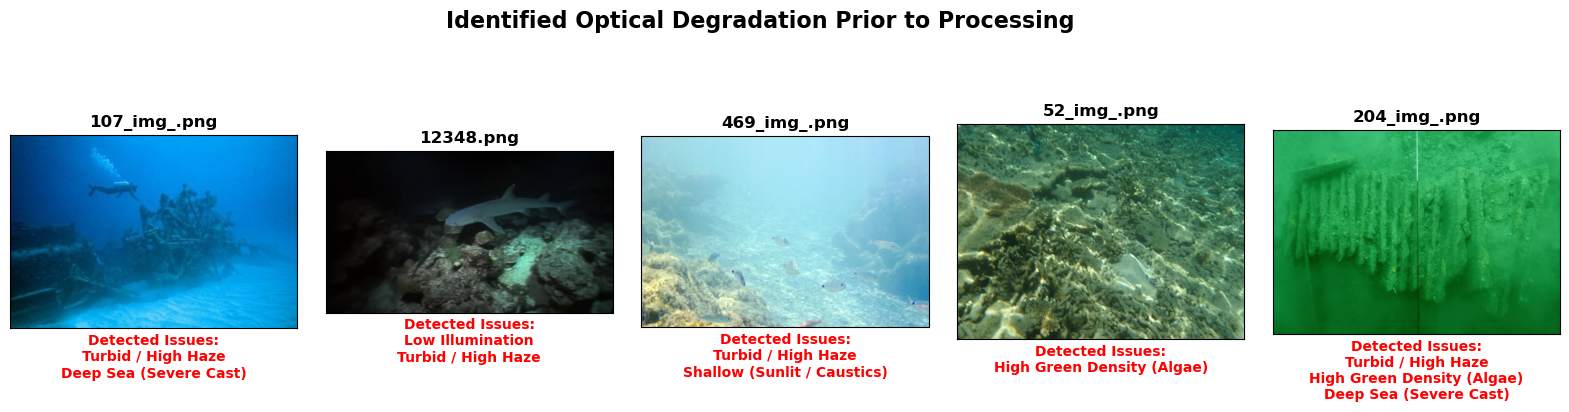

In [2]:
target_images = ["107_img_.png", "12348.png", "469_img_.png", "52_img_.png", "204_img_.png"]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
plt.subplots_adjust(wspace=0.1)

for idx, filename in enumerate(target_images):
    img_path = os.path.join(RAW_PATH, filename)
    img = cv2.imread(img_path)
    
    # Look up the tags for this specific image from our CSV
    image_data = df_profile[df_profile['Filename'] == filename]
    
    if img is not None and not image_data.empty:
        tags = image_data.iloc[0]['Category_Tags']
        
        ax = axes[idx]
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(filename, fontsize=12, fontweight='bold')
        
        # Display the tags below the image, replacing '+' with newlines for clean formatting
        formatted_tags = tags.replace(" + ", "\n")
        ax.set_xlabel(f"Detected Issues:\n{formatted_tags}", fontsize=10, color='red', fontweight='semibold')
        ax.set_xticks([]); ax.set_yticks([])
    else:
        axes[idx].set_title(f"Missing: {filename}")
        axes[idx].axis('off')

plt.suptitle("Identified Optical Degradation Prior to Processing", fontsize=16, fontweight='bold', y=1.05)
plt.show()

---
## 4.4 Large-Scale Dataset Execution
The adaptive pipeline is now deployed across the entire dataset. Each image is dynamically processed based on its unique CSV profile. The calibrated outputs are saved to the master directory for subsequent neural network training.

In [3]:
print(f"Deploying Adaptive Pipeline on {len(df_profile)} images...")

for index, row in tqdm(df_profile.iterrows(), total=len(df_profile), desc="Processing Database"):
    filename = row['Filename']
    tags = row['Category_Tags']
    
    img_path = os.path.join(RAW_PATH, filename)
    img = cv2.imread(img_path)
    
    if img is None: continue
        
    # Pass the image and its specific multi-label tags into the router
    final_enhanced_img = intelligent_enhance(img, tags)
    
    # Save the processed image
    output_path = os.path.join(ADAPTIVE_OUT, filename)
    cv2.imwrite(output_path, final_enhanced_img)

print(f"\nSuccess! All images dynamically processed and saved to: {ADAPTIVE_OUT}")

Deploying Adaptive Pipeline on 890 images...


Processing Database: 100%|███████████████████████████████████████████████████████████| 890/890 [02:15<00:00,  6.56it/s]


Success! All images dynamically processed and saved to: C:/Users/huiki/Desktop/FYP/data/processed/adaptive_pipeline/


---
## 4.5 Qualitative & Quantitative Visual Assessment
To validate the success of the adaptive logic, we evaluate the 5 representative images. A successful enhancement will yield increased structural sharpness (UIQM) and recovered chromaticity (UCIQE), while visually eliminating the initial issues diagnosed in Section 4.3.

Generating Before/After Assessment Grid...


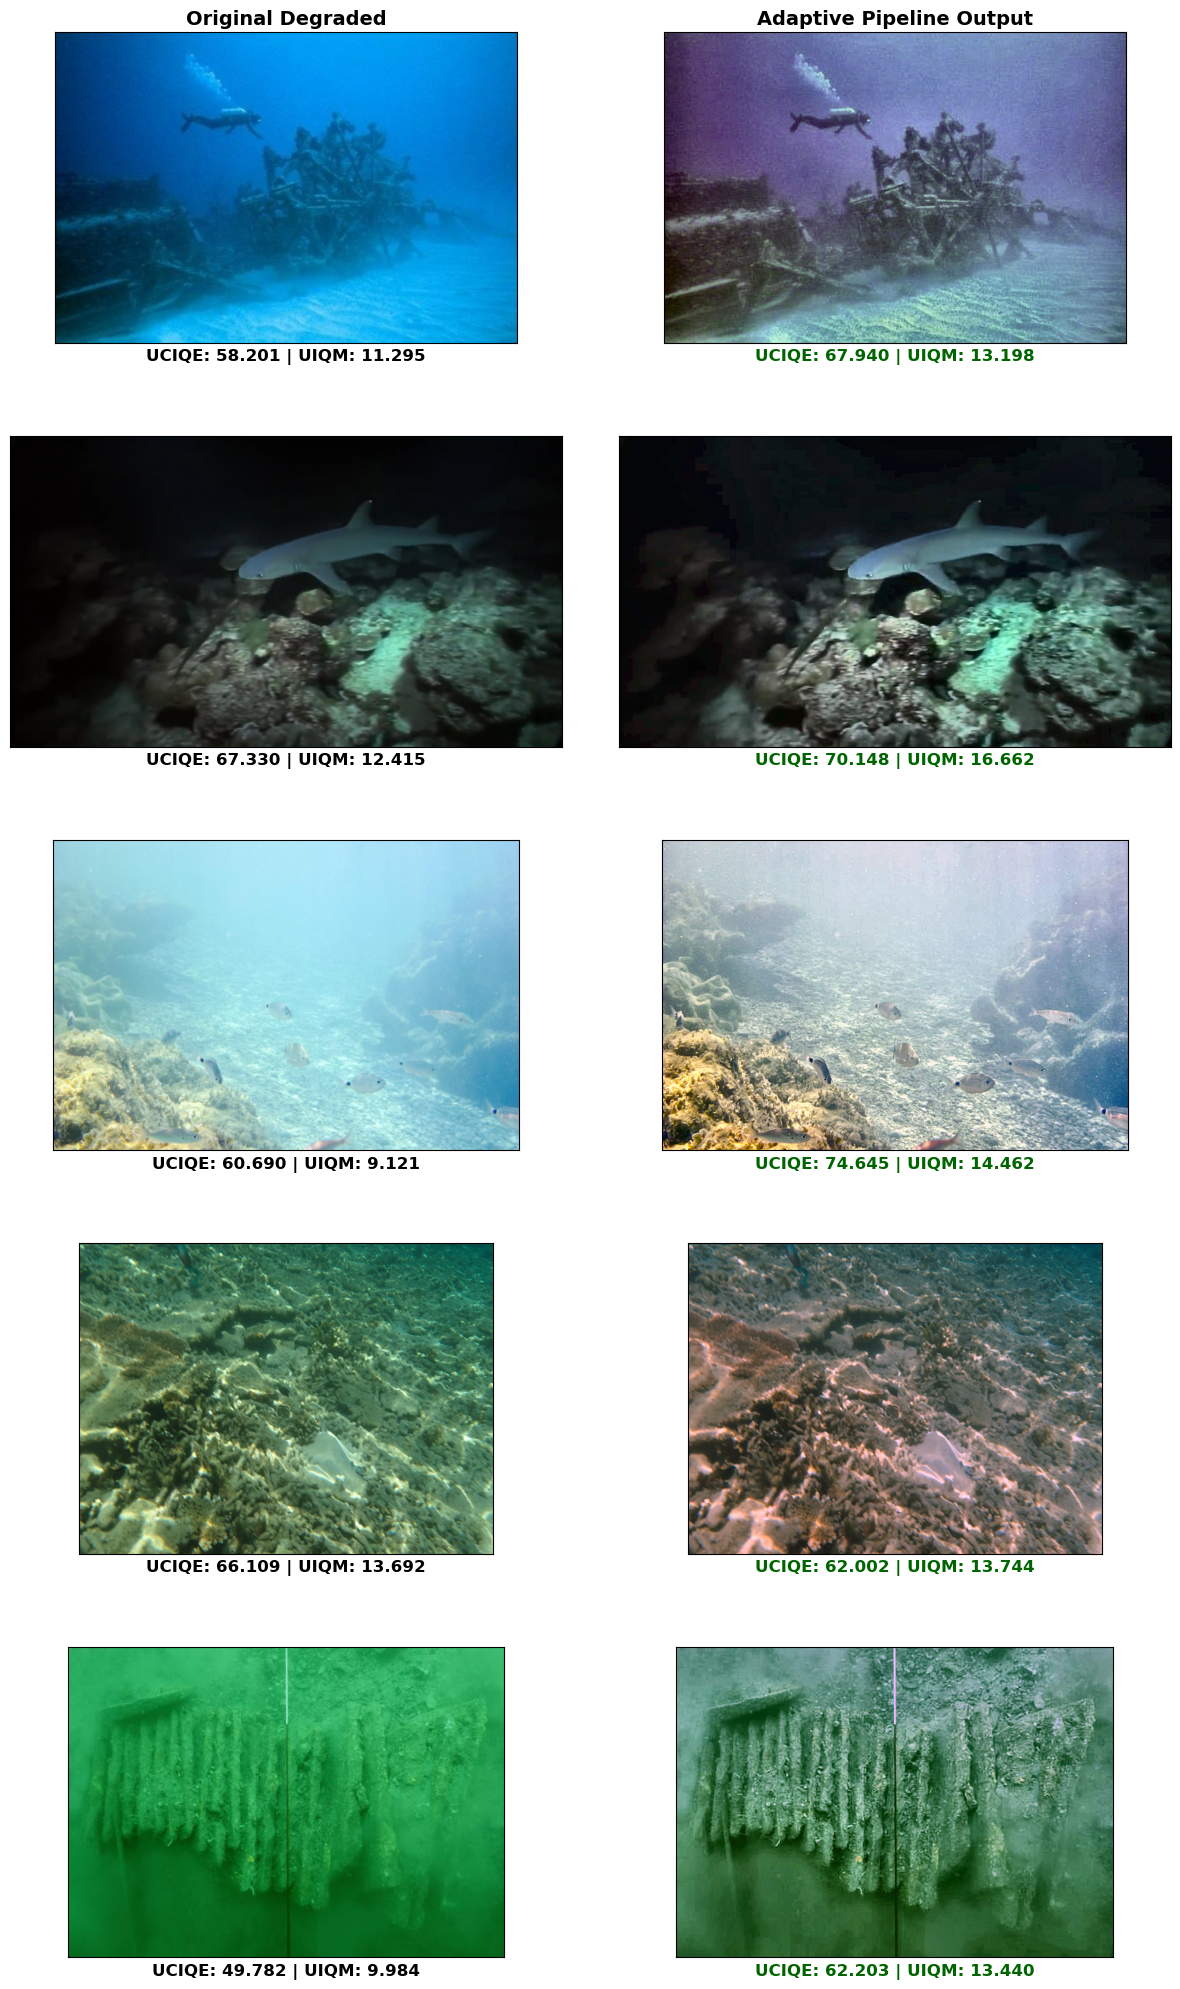

Assessment grid saved to: C:/Users/huiki/Desktop/FYP/data/processed/adaptive_pipeline/adaptive_assessment_grid.png


In [4]:
def calculate_uciqe(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    sigma_c = np.std(np.sqrt(np.square(lab[:,:,1].astype(np.float32)) + np.square(lab[:,:,2].astype(np.float32))))
    con_l = np.max(lab[:,:,0]) - np.min(lab[:,:,0])
    mu_s = np.mean(hsv[:,:,1]) / 255.0
    return (0.4680 * sigma_c) + (0.2745 * con_l) + (0.2576 * mu_s)

def calculate_uiqm(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    sharpness = np.mean(np.sqrt(sobelx**2 + sobely**2))
    contrast = np.std(gray)
    return (0.0282 * sharpness) + (0.2953 * contrast) + 1.5

fig, axes = plt.subplots(nrows=len(target_images), ncols=2, figsize=(15, 5 * len(target_images)))
plt.subplots_adjust(hspace=0.3, wspace=0.1)

print("Generating Before/After Assessment Grid...")

for idx, filename in enumerate(target_images):
    orig_path = os.path.join(RAW_PATH, filename)
    proc_path = os.path.join(ADAPTIVE_OUT, filename) # Loading the newly saved images
    
    orig_bgr = cv2.imread(orig_path)
    proc_bgr = cv2.imread(proc_path)
    
    if orig_bgr is None or proc_bgr is None: continue
        
    variants = [
        ("Original Degraded", orig_bgr, 'black'),
        ("Adaptive Pipeline Output", proc_bgr, 'darkgreen')
    ]
    
    for col_idx, (name, img_data, text_color) in enumerate(variants):
        ax = axes[idx][col_idx]
        ax.imshow(cv2.cvtColor(img_data, cv2.COLOR_BGR2RGB))
        
        # Calculate Assessment Metrics
        uciqe = calculate_uciqe(img_data)
        uiqm = calculate_uiqm(img_data)
        
        if idx == 0:
            ax.set_title(name, fontsize=14, fontweight='bold')
            
        ax.set_xlabel(f"UCIQE: {uciqe:.3f} | UIQM: {uiqm:.3f}", 
                     fontsize=12, fontweight='bold', color=text_color)
        ax.set_xticks([]); ax.set_yticks([])

# Save the validation grid for the thesis document
eval_grid_path = os.path.join(ADAPTIVE_OUT, "adaptive_assessment_grid.png")
plt.savefig(eval_grid_path, bbox_inches='tight', dpi=300)
plt.show()

print(f"Assessment grid saved to: {eval_grid_path}")

---
## 4.6 Quantitative Performance Summary & Algorithm Superiority

While visual assessment is necessary for qualitative validation, objective numerical superiority must be established. This section aggregates the evaluation metrics (UCIQE and UIQM) to calculate the global mean improvements.

Furthermore, we calculate the **Algorithm Superiority Rate** (the percentage of instances where the adaptive pipeline mathematically outperformed the baseline degraded image). This metric proves the consistency and reliability of the intelligent routing logic.

In [5]:
print("Extracting metrics for performance summary...")

# 1. Gather the data into a list (using the 5 target images from Section 4.5)
# Note: You can easily expand this loop to your entire dataset later!
summary_data = []

for filename in target_images:
    orig_path = os.path.join(RAW_PATH, filename)
    proc_path = os.path.join(ADAPTIVE_OUT, filename)
    
    orig_bgr = cv2.imread(orig_path)
    proc_bgr = cv2.imread(proc_path)
    
    if orig_bgr is None or proc_bgr is None: continue
        
    summary_data.append({
        "Filename": filename,
        "Original_UIQM": calculate_uiqm(orig_bgr),
        "Adaptive_UIQM": calculate_uiqm(proc_bgr),
        "Original_UCIQE": calculate_uciqe(orig_bgr),
        "Adaptive_UCIQE": calculate_uciqe(proc_bgr)
    })

# 2. Convert to Pandas DataFrame
df_results = pd.DataFrame(summary_data)

# ==========================================
# 3. Calculate Mean Scores
# ==========================================
print("\n=== Global Mean Scores ===")
# Drop the filename column so we only calculate the mean of the numbers
mean_summary = df_results.drop(columns=['Filename']).mean().sort_values(ascending=False)
print(mean_summary.round(3))

# ==========================================
# 4. Calculate Algorithm Superiority Rate 
# ==========================================
# Identify which column has the highest UIQM for each row
uiqm_cols = ['Original_UIQM', 'Adaptive_UIQM']
df_results['Superior_Method'] = df_results[uiqm_cols].idxmax(axis=1)

print("\n=== Algorithm Superiority Rate (UIQM) ===")
# Calculate the percentage of times each method was the "winner"
superiority_rate = df_results['Superior_Method'].value_counts(normalize=True).mul(100).round(1)
print(superiority_rate.astype(str) + '%')

Extracting metrics for performance summary...

=== Global Mean Scores ===
Adaptive_UCIQE    67.388
Original_UCIQE    60.422
Adaptive_UIQM     14.301
Original_UIQM     11.301
dtype: float64

=== Algorithm Superiority Rate (UIQM) ===
Superior_Method
Adaptive_UIQM    100.0%
Name: proportion, dtype: object
